In [1]:
%%time

import os, sys # Operating system and system-specific parameters
from IPython.utils import io # Input/output utilities
import time # Time-related functions
from datetime import datetime as dt # Date and time objects
from pytz import timezone # Timezone handling

os.environ['TZ'] = 'America/Bogota'

time.tzset()
print(f"Current time in Bogota: {dt.now().strftime('%y-%m-%d_%H:%M:%S.')}")

with io.capture_output() as cap:
  !pip install datascience

with open('./pip_installs.txt', 'w') as f: # Open file for writing pip installs
    f.write(cap.stdout) # Write captured output to file
!pip freeze > requirements.txt # Save all installed packages to requirements.txt

Current time in Bogota: 26-09-04_10:04:27.
CPU times: user 2.35 s, sys: 867 ms, total: 3.21 s
Wall time: 22.5 s


# Laboratorio: Naive Bayes Bernoulli para detectar spam

## Objetivo
Construir desde cero un clasificador **Naive Bayes Bernoulli** a partir de un corpus pequeño de correos.

Al terminar debes poder explicar y calcular:

$
P(Y),\qquad P(X_i\mid Y),\qquad P(X\mid Y),\qquad P(Y\mid X)
$

y comprender por qué la hipótesis

$
X_i \perp X_j\mid Y
$

reduce drásticamente la complejidad del modelo.

## Contexto

Queremos clasificar un correo como

$
Y=1:\ \text{spam}, \qquad Y=0:\ \text{normal}.
$

Usaremos cinco palabras del vocabulario:


$V=\{\text{dinero, gratis, premio, proyecto, reunion}\}.$

Cada correo se representa por

$X=(X_1,\ldots,X_5),$

donde

$
X_i=\begin{cases}
1 & \text{si aparece la palabra }i,\\
0 & \text{si no aparece.}
\end{cases}
$
Por ejemplo, "dinero gratis" se representa como $(1,1,0,0,0).$


In [2]:
import numpy as np
import pandas as pd
import itertools as it
import datascience as ds
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits


from pprint import pprint
from IPython.display import display, Image, display_svg # Display functions
from IPython.display import Markdown, Math, Latex # Text formatting
from IPython.display import Javascript, IFrame, HTML # Web elements

def dLatex(self):
  # Displays the input string as LaTeX.
  return display(Latex(self))
def dMarkdown(self):
  # Displays the input string as Markdown.
  return display(Markdown(self))

# Avoids scroll-in-the-scroll in the entire Notebook
# https://stackoverflow.com/a/66891328
def resize_colab_cell():
  display(Javascript(
      'google.colab.output.setIframeHeight'+
      '(0, true, {maxHeight: 4000})'
      ))
get_ipython().events.register(
    'pre_run_cell',resize_colab_cell)

In [3]:
corpus = {
    "gana dinero gratis": "spam",
    "dinero gratis ahora": "spam",
    "premio dinero gratis": "spam",
    "gana premio ahora": "spam",
    "en la reunion habra dinero gratis": "spam",
    "daremos un premio despues de la reunion": "normal",
    "reunion de proyecto": "normal",
    "proyecto para mañana": "normal",
    "reunion mañana": "normal",
    "informe del proyecto": "normal",
    "informe del proyecto": "normal"
}

t_vec = np.array(tuple(corpus.keys()))
y_vec = np.array(tuple(corpus.values()))

corpus_table = pd.DataFrame.from_dict(
    {"texto": t_vec,
     "etiqueta": y_vec
     })

todas_las_palabras = set(" ".join(corpus_table['texto']).lower().split())

vocabulario_p = {"dinero", "gratis", "premio", "proyecto", "reunion", "criptomoneda"}
vocabulario_s = todas_las_palabras - vocabulario_p

# Ordenamos el vocabulario principal y secundario alfabéticamente
sorted_vocabulario_p = sorted(list(vocabulario_p))
sorted_vocabulario_s = sorted(list(vocabulario_s))

dMarkdown(f"**Vocabulario principal ordenado:**<br> {sorted_vocabulario_p}")
dMarkdown(f"**Vocabulario principal ordenado:**<br> {sorted_vocabulario_s}")
display(corpus_table)

<IPython.core.display.Javascript object>

**Vocabulario principal ordenado:**<br> ['criptomoneda', 'dinero', 'gratis', 'premio', 'proyecto', 'reunion']

**Vocabulario principal ordenado:**<br> ['ahora', 'daremos', 'de', 'del', 'despues', 'en', 'gana', 'habra', 'informe', 'la', 'mañana', 'para', 'un']

,texto,etiqueta
0,gana dinero gratis,spam
1,dinero gratis ahora,spam
2,premio dinero gratis,spam
3,gana premio ahora,spam
4,en la reunion habra dinero gratis,spam
5,daremos un premio despues de la reunion,normal
6,reunion de proyecto,normal
7,proyecto para mañana,normal
8,reunion mañana,normal
9,informe del proyecto,normal


## Parte 1 — Construir el vector \(X\)

1. Escribe una función `vectorizar(texto, vocabulario)` que transforme un correo en un vector binario.
2. Vectoriza todos los correos del corpus.
3. Verifica manualmente al menos dos ejemplos.

Ejemplo esperado:

**gana dinero gratis** $\longrightarrow(1,1,0,0,0)$


In [4]:
# Función para convertir un texto en un vector binario basado en el vocabulario
def vectorizar(texto, sorted_vocabulario):
    palabras = set(texto.lower().split())
    # Vector booleano según de cada palabra ordenada
    return np.fromiter(
        (1 if palabra in palabras else 0 for palabra in sorted_vocabulario),
        dtype=bool)

# Vectorizamos todos los textos del corpus usando el vocabulario principal
Xp = np.array([vectorizar(texto, sorted_vocabulario_p) for texto in t_vec])
Xs = np.array([vectorizar(texto, sorted_vocabulario_s) for texto in t_vec])

# Mostramos el vocabulario y actualizamos la tabla del corpus con los nuevos vectores
dMarkdown(f"**Vocabulario ordenado:**<br> {sorted_vocabulario_p}")
corpus_table["vector_p"] = list(Xp)
corpus_table["vector_s"] = list(Xs)

# Formatter function to render array/list as a bit string
fmt_bitstring = lambda arr: "".join(str(int(b)) for b in arr)

# Visual-only display (original df remains untouched)
corpus_table.style.format({
    "vector_p": fmt_bitstring,
    "vector_s": fmt_bitstring
})

<IPython.core.display.Javascript object>

**Vocabulario ordenado:**<br> ['criptomoneda', 'dinero', 'gratis', 'premio', 'proyecto', 'reunion']

,texto,etiqueta,vector_p,vector_s
0,gana dinero gratis,spam,011000,0000001000000
1,dinero gratis ahora,spam,011000,1000000000000
2,premio dinero gratis,spam,011100,0000000000000
3,gana premio ahora,spam,000100,1000001000000
4,en la reunion habra dinero gratis,spam,011001,0000010101000
5,daremos un premio despues de la reunion,normal,000101,0110100001001
6,reunion de proyecto,normal,000011,0010000000000
7,proyecto para mañana,normal,000010,0000000000110
8,reunion mañana,normal,000001,0000000000100
9,informe del proyecto,normal,000010,0001000010000


## Parte 2 — Calcular el prior \(P(Y)\)

$$
P(Y=y)=\frac{\#\text{correos de clase }y}{\#\text{correos totales}}.
$$

Calcula:

$$P(Y=\text{spam}),\quad P(Y=\text{normal}).$$

In [5]:
# Contamos cuántas veces aparece cada etiqueta en la columna 'etiqueta'
counts = corpus_table["etiqueta"].value_counts()
correos_totales = len(corpus_table)

# Calculamos las probabilidades a priori
P_spam = counts["spam"] / correos_totales
P_normal = counts["normal"] / correos_totales

# Mostramos los resultados usando formato LaTeX en Markdown
dMarkdown(f"$P(Y=\\text{{spam}})={P_spam}$")
dMarkdown(f"$P(Y=\\text{{normal}})={P_normal}$")

<IPython.core.display.Javascript object>

$P(Y=\text{spam})=0.5$

$P(Y=\text{normal})=0.5$

## Parte 3 — Calcular $P(X_i=1\mid Y)$

Para cada palabra calcula su frecuencia dentro de cada clase. Por ejemplo:

$$
P(X_{dinero}=1\mid Y=spam)
=\frac{\#\text{spam que contienen dinero}}{\#\text{spam}}.
$$

Construye una tabla con las cinco palabras y ambas clases.

**Pregunta:** ¿qué ocurre si una palabra nunca aparece en una clase?

In [6]:
dMarkdown("""
Si una palabra nunca aparece en una clase,<br>
su probabilidad condicional
$P(X_i=1|Y)$ será exactamente cero.
""")

def calcular_probabilidades(corpus_table, column_name, sorted_vocabulario):
  # Separamos los vectores por clase
  spam_vectors = np.array(corpus_table[corpus_table['etiqueta'] == 'spam'][column_name].tolist())
  normal_vectors = np.array(corpus_table[corpus_table['etiqueta'] == 'normal'][column_name].tolist())
  # Calculamos la probabilidad condicional P(Xi=1 | Y) sin suavizado
  # Sumamos las columnas y dividimos por el total de la clase
  prob_cond_spam = spam_vectors.sum(axis=0) / len(spam_vectors)
  prob_cond_normal = normal_vectors.sum(axis=0) / len(normal_vectors)

  # Creamos una tabla para visualizar los resultados
  cond_table = pd.DataFrame({
      "Palabra": sorted_vocabulario,
      "P(X_i=1|Y=spam)": prob_cond_spam,
      "P(X_i=1|Y=normal)": prob_cond_normal
  })
  return cond_table.set_index("Palabra")

cond_table_p = calcular_probabilidades(
    corpus_table, "vector_p", sorted_vocabulario_p)
cond_table_s = calcular_probabilidades(
    corpus_table, "vector_s", sorted_vocabulario_s)

dMarkdown("**Probabilidades Condicionales (Vocabulario Principal):**")
display(cond_table_p)

dMarkdown("**Probabilidades Condicionales (Vocabulario Secundario):**")
display(cond_table_s)

<IPython.core.display.Javascript object>


Si una palabra nunca aparece en una clase,<br>
su probabilidad condicional
$P(X_i=1|Y)$ será exactamente cero.


**Probabilidades Condicionales (Vocabulario Principal):**

,P(X_i=1|Y=spam),P(X_i=1|Y=normal)
Palabra,,
criptomoneda,0.0,0.0
dinero,0.8,0.0
gratis,0.8,0.0
premio,0.4,0.2
proyecto,0.0,0.6
reunion,0.2,0.6


**Probabilidades Condicionales (Vocabulario Secundario):**

,P(X_i=1|Y=spam),P(X_i=1|Y=normal)
Palabra,,
ahora,0.4,0.0
daremos,0.0,0.2
de,0.0,0.4
del,0.0,0.2
despues,0.0,0.2
en,0.2,0.0
gana,0.4,0.0
habra,0.2,0.0
informe,0.0,0.2


## Parte 4 — Suavizado de Laplace

Para evitar probabilidades exactamente iguales a cero, usa suavizado de Laplace para variables Bernoulli:


$$\hat P(X_i=1\mid Y=y)=\frac{N_{iy}+1}{N_y+2},$$


donde \(N_{iy}\) es el número de correos de clase \(y\) que contienen la palabra \(i\), y \(N_y\) es el número total de correos de esa clase.

Calcula de nuevo la tabla.

In [7]:
def calcular_probabilidades_laplace(corpus_table, column_name, sorted_vocabulario):
  # Separamos los vectores por clase
  spam_vectors = np.array(corpus_table[corpus_table['etiqueta'] == 'spam'][column_name].tolist())
  normal_vectors = np.array(corpus_table[corpus_table['etiqueta'] == 'normal'][column_name].tolist())
  # Calculamos la probabilidad condicional con suavizado de Laplace: (Niy + 1) / (Ny + 2)
  # Sumamos las columnas y dividimos por el total de la clase
  prob_cond_spam = (spam_vectors.sum(axis=0) + 1) / (len(spam_vectors) + 2)
  prob_cond_normal = (normal_vectors.sum(axis=0) + 1) / (len(normal_vectors) + 2)
  # Creamos una tabla para visualizar los resultados
  Laplace_table = pd.DataFrame({
      "Palabra": sorted_vocabulario,
      "PL(X_i=1|Y=spam)": prob_cond_spam,
      "PL(X_i=1|Y=normal)": prob_cond_normal
  })
  return Laplace_table.set_index("Palabra")

# Calculamos las tablas con Laplace
Laplace_table_p = calcular_probabilidades_laplace(corpus_table, "vector_p", sorted_vocabulario_p)
Laplace_table_s = calcular_probabilidades_laplace(corpus_table, "vector_s", sorted_vocabulario_s)

# Combinamos con las tablas originales usando right_index=True para corregir el MergeError
conds_table_p = pd.merge(cond_table_p, Laplace_table_p, left_index=True, right_index=True)
conds_table_s = pd.merge(cond_table_s, Laplace_table_s, left_index=True, right_index=True)

dMarkdown("### Resultados con Suavizado de Laplace (Vocabulario Principal)")
display(conds_table_p)
dMarkdown("### Resultados con Suavizado de Laplace (Vocabulario Secundario)")
display(conds_table_s)

<IPython.core.display.Javascript object>

### Resultados con Suavizado de Laplace (Vocabulario Principal)

,P(X_i=1|Y=spam),P(X_i=1|Y=normal),PL(X_i=1|Y=spam),PL(X_i=1|Y=normal)
Palabra,,,,
criptomoneda,0.0,0.0,0.142857,0.142857
dinero,0.8,0.0,0.714286,0.142857
gratis,0.8,0.0,0.714286,0.142857
premio,0.4,0.2,0.428571,0.285714
proyecto,0.0,0.6,0.142857,0.571429
reunion,0.2,0.6,0.285714,0.571429


### Resultados con Suavizado de Laplace (Vocabulario Secundario)

,P(X_i=1|Y=spam),P(X_i=1|Y=normal),PL(X_i=1|Y=spam),PL(X_i=1|Y=normal)
Palabra,,,,
ahora,0.4,0.0,0.428571,0.142857
daremos,0.0,0.2,0.142857,0.285714
de,0.0,0.4,0.142857,0.428571
del,0.0,0.2,0.142857,0.285714
despues,0.0,0.2,0.142857,0.285714
en,0.2,0.0,0.285714,0.142857
gana,0.4,0.0,0.428571,0.142857
habra,0.2,0.0,0.285714,0.142857
informe,0.0,0.2,0.142857,0.285714


## Parte 5 — Clasificar un correo nuevo

Clasifica:

> **"dinero gratis"**

Su vector es

$x=(0,1,1,0,0,0).$



In [8]:
nuevo_correo = "dinero gratis"
x_nuevo = vectorizar(nuevo_correo, sorted_vocabulario_p)
dMarkdown(f"**Vector binario para '{nuevo_correo}':** ${fmt_bitstring(x_nuevo)}$")

<IPython.core.display.Javascript object>

**Vector binario para 'dinero gratis':** $011000$

Bajo Naive Bayes Bernoulli:

$$P(x\mid Y=y)=\prod_iP(X_i=x_i\mid Y=y).$$

Recuerda que para una palabra ausente:

$$P(X_i=0\mid Y=y)=1-P(X_i=1\mid Y=y).$$

In [9]:
# Extracción de probabilidades condicionales con Laplace
p_cond_spam = conds_table_p['PL(X_i=1|Y=spam)'].values
p_cond_normal = conds_table_p['PL(X_i=1|Y=normal)'].values

# Definición de la función de verosimilitud Bernoulli
def calcular_likelihood(x, p_cond):
    # P(x_i | Y)          si x_i=1
    # (1 - P(x_i | Y))    si x_i=0
    probs = np.where(x, p_cond, 1 - p_cond)
    # Calcular productoria
    return probs, np.prod(probs)

# Calcular verosimilitudes con suavizado de Laplace
probs_spam, likelihood_spam = calcular_likelihood(x_nuevo, p_cond_spam)
probs_normal, likelihood_normal = calcular_likelihood(x_nuevo, p_cond_normal)

# Visualización con etiquetas corregidas
dMarkdown(f"""
* **Verosimilitud para Spam:**<br> $P(x \\mid Y=spam) = {likelihood_spam:.4f}$ <br> Factores: {np.round(probs_spam, 4)}")
* **Verosimilitud para Normal:**<br> $P(x \\mid Y=normal) = {likelihood_normal:.4f}$ <br> Factores: {np.round(probs_normal, 4)}
""")

<IPython.core.display.Javascript object>


* **Verosimilitud para Spam:**<br> $P(x \mid Y=spam) = 0.1530$ <br> Factores: [ 0.8571  0.7143  0.7143  0.5714  0.8571  0.7143]")
* **Verosimilitud para Normal:**<br> $P(x \mid Y=normal) = 0.0023$ <br> Factores: [ 0.8571  0.1429  0.1429  0.7143  0.4286  0.4286]


Calcula los scores conjuntos:

$$S_y=P(Y=y)P(x\mid Y=y),$$

In [10]:
# Cálculo de Scores Conjuntos: S_y = P(Y)*P(x|Y)
score_spam   = P_spam * likelihood_spam
score_normal = P_normal * likelihood_normal

dMarkdown(f"""
**Scores Conjuntos $S_y = P(Y) \\cdot P(x \\mid Y)$:**
* $S_{{spam}} = {P_spam} \\cdot {likelihood_spam:.4f} = {score_spam:.4f}$
* $S_{{normal}} = {P_normal} \\cdot {likelihood_normal:.4f} = {score_normal:.4f}$
""")

<IPython.core.display.Javascript object>


**Scores Conjuntos $S_y = P(Y) \cdot P(x \mid Y)$:**
* $S_{spam} = 0.5 \cdot 0.1530 = 0.0765$
* $S_{normal} = 0.5 \cdot 0.0023 = 0.0011$


y finalmente:

$P(Y=y\mid x)=\frac{S_y}{S_{spam}+S_{normal}}.$

Decide la clase del correo.

In [11]:
# Cálculo de Probabilidades Posteriores: P(Y|x)
evidencia = score_spam + score_normal
posterior_spam = score_spam / evidencia
posterior_normal = score_normal / evidencia

etiqueta_nuevo = 'spam' if posterior_spam > posterior_normal else 'normal'
simbolo_nuevo = '>' if posterior_spam > posterior_normal else '<'

# Visualización de resultados en formato Bayesiano
dMarkdown(f"""
#### Evidencia (Denominador):
* $P(x) = S_{{\\text{{spam}}}} + S_{{\\text{{normal}}}} = {evidencia:.4f}$

#### Probabilidades Posteriores:
* $P(Y=\\text{{spam}} \\mid x) = \\tfrac{{{score_spam:.4f}}}{{{evidencia:.4f}}} = {posterior_spam:.4f}$
* $P(Y=\\text{{normal}} \\mid x) = \\tfrac{{{score_normal:.4f}}}{{{evidencia:.4f}}} = {posterior_normal:.4f}$

#### Conclusión:
* Dado que $P(\\text{{spam}}|x) {simbolo_nuevo} P(normal|x)$,<br>
el correo se clasifica como **{etiqueta_nuevo.upper()}**.
""")

<IPython.core.display.Javascript object>


#### Evidencia (Denominador):
* $P(x) = S_{\text{spam}} + S_{\text{normal}} = 0.0776$

#### Probabilidades Posteriores:
* $P(Y=\text{spam} \mid x) = \tfrac{0.0765}{0.0776} = 0.9852$
* $P(Y=\text{normal} \mid x) = \tfrac{0.0011}{0.0776} = 0.0148$

#### Conclusión:
* Dado que $P(\text{spam}|x) > P(normal|x)$,<br>
el correo se clasifica como **SPAM**.


## Parte 6 — Interpretación

Responde brevemente:

1. ¿Dónde se usa la hipótesis de independencia condicional?
2. ¿Por qué no necesitamos almacenar una probabilidad para cada uno de los $2^5$ vectores posibles?
3. ¿Por qué Naive Bayes se considera un modelo **generativo** aunque aquí lo usemos para clasificar?

### ¿Dónde se usa la hipótesis de independencia condicional?

La hipótesis de Bernoulli Naive Bayes de independencia condicional asume que todas las características o predictores $X$ son condicionalmente independientes entre sí, dado el valor de la clase $Y$.Se utiliza específicamente al calcular la verosimilitud $P(\mathbf{x} \mid Y)$. En lugar de estimar la probabilidad conjunta de todas las posibles combinaciones de palabras simultáneas en el vocabulario —lo cual requeriría una cantidad gigantesca de datos—, asumimos que la presencia de cada palabra es independiente de las demás dada la clase. Esto permite descomponer la verosimilitud en el producto de las probabilidades individuales:

$$P(\mathbf{x} \mid Y) = \prod_{i=1}^{n} P(x_i \mid Y)$$

Donde $\mathbf{x} = (x_1, x_2, \dots, x_n)$ representa el vector de características del mensaje.

### ¿Por qué no necesitamos almacenar una probabilidad para cada uno de los $2^5$ vectores posibles?  

En lugar de estimar un vector gigantesco $\hat{\boldsymbol{\theta}}_c \in \mathbb{R}^{2^d - 1}$ para todas las combinaciones posibles de palabras, la hipótesis de Naive Bayes reduce el modelo a un único vector booleano de dimensión $d$:

$$\hat{\boldsymbol{\theta}} = (\hat{\theta}_{1}, \, \hat{\theta}_{2}, \, \dots, \, \hat{\theta}_{d})^\top \in [0, 1]^d,$$

pasas de un problema de crecimiento exponencial $2^d - 1$ parámetros, a solo uno lineal $d$.

Cada componente de verosimilitud $P(X_i = 1 \mid Y = c)$ es simplemente la probabilidad de que la palabra $i$ aparezca en la clase $y$ ('spam' o 'normal'), se calcula multiplicando directamente las componentes:

$$P(x\mid Y=y)=\prod_iP(X_i=x_i\mid Y=y).$$

Teniendo en cuenta que:

$$P(X_i=0\mid Y=y)=1-P(X_i=1\mid Y=y).$$

De forma mas general:

$$P(\mathbf{x} \mid Y = c) = \prod_{i=1}^{d} \hat{\theta}_{c,i}^{x_i} (1 - \hat{\theta}_{c,i})^{1 - x_i}$$



### ¿Por qué Naive Bayes se considera un modelo generativo aunque aquí lo usemos para clasificar?
A diferencia de los modelos discriminativos (como la Regresión Logística o SVM), que aprenden directamente la frontera de decisión modelando el posterior $P(Y \mid X)$, Naive Bayes modela la distribución de probabilidad conjunta:

$$P(X, Y) = P(Y) \cdot P(X \mid Y)$$

Donde $P(Y)$ es la probabilidad a priori de la clase, y $P(X \mid Y)$ (verosimilitud) es la probabilidad de observar las características $X$ dada la clase $Y$.

In [12]:
a = np.fromiter(it.product(["T", "H"], repeat=4), dtype=object)
S = ["".join(x) for x in a]
omega = ds.make_array(S)[0]

print(omega)

<IPython.core.display.Javascript object>

['TTTT' 'TTTH' 'TTHT' 'TTHH' 'THTT' 'THTH' 'THHT' 'THHH' 'HTTT' 'HTTH'
 'HTHT' 'HTHH' 'HHTT' 'HHTH' 'HHHT' 'HHHH']


¿Cual es la probabilidad de obtener una cara seguida de un sello?


$A = \{HT\}$

$P_{data}(A)$

In [13]:
Pdata = ds.Table().with_columns(
    "omega", omega,
    "Pdata", np.ones(len(omega))/len(omega)
    )
Pdata.sample(10)

<IPython.core.display.Javascript object>

omega,Pdata
TTHT,0.0625
TTTT,0.0625
TTHT,0.0625
THTH,0.0625
TTHT,0.0625
THHH,0.0625
HTHT,0.0625
HHHT,0.0625
THTH,0.0625
HTHT,0.0625


In [14]:
pHT = Pdata.where(omega, ds.are.containing("HT")).column("Pdata").sum()
Pteorico = pHT

dMarkdown(f"""
### Resultado de Probabilidad
* **Probabilidad calculada $(P_{{HT}})$:** ${Pteorico:.4f}$
* **Diferencia con el valor teórico $(11/16)$:** ${Pteorico - 11/16:.4f}$
""")

<IPython.core.display.Javascript object>


### Resultado de Probabilidad
* **Probabilidad calculada $(P_{HT})$:** $0.6875$
* **Diferencia con el valor teórico $(11/16)$:** $0.0000$


In [15]:
# Observaciones
Nsample = 25
Lanzamientos = Pdata.select("omega").sample(Nsample)

# Distribucion empirica de los datos
pHTempirica = Lanzamientos.where("omega", ds.are.containing("HT")).column("omega")

# Conteo directo
Pemp = len(pHTempirica) / Nsample

dMarkdown(f"""
### Análisis de Muestreo Empírico $(N={Nsample})$

* **Muestras que contienen 'HT':** {len(pHTempirica)}
* **Probabilidad Empírica $(\\hat{{P}})$:** ${Pemp:.4f}$
* **Probabilidad Teórica $(P)$:** ${Pteorico:.4f}$
* **Error de estimación:** ${abs(Pemp - Pteorico):.4f}$
""")

<IPython.core.display.Javascript object>


### Análisis de Muestreo Empírico $(N=25)$

* **Muestras que contienen 'HT':** 18
* **Probabilidad Empírica $(\hat{P})$:** $0.7200$
* **Probabilidad Teórica $(P)$:** $0.6875$
* **Error de estimación:** $0.0325$


Supongamos un modelo en el que las variables aleatorias son independientes(en el caso de la moneda coinciden) :



Estimemos los cuatro parámetros desde los datos: $\theta=(p_1,p_2,p_3,p_4)$

$P_{\theta}(A) = P(x_1)P(x_2)P(x_3)P(x_4) $



Una cara seguida de un sello  el evento es:

$A_1= \{X_1 = H,X_2=T\}$, $A_2= \{X_2 = H,X_3=T\}$, $A_3= \{X_3 = H,X_4=T\}$

Como A1 y A3 se cuentan dos veces


$p = p_1(1-p_2)+ p_2(1-p_3) + p_3(1-p_4)- p_1(1-p_2)p_3(1-p_4)$

In [16]:
# Independencia
# Primero intentamos aprender las probabilidades de cara en cada posición:
p1 = np.mean([x[0] == "H" for x in Lanzamientos.column("omega")])
p2 = np.mean([x[1] == "H" for x in Lanzamientos.column("omega")])
p3 = np.mean([x[2] == "H" for x in Lanzamientos.column("omega")])
p4 = np.mean([x[3] == "H" for x in Lanzamientos.column("omega")])

pcara = np.array([p1, p2, p3, p4])
psello = 1 - pcara

# Probabilidad bajo hipótesis de independencia para el evento 'al menos un HT'
p = p1*(1-p2) + p2*(1-p3) + p3*(1-p4) - p1*(1-p2)*p3*(1-p4)

PthetaA = p

dMarkdown(f"""
### Comparativa de Modelos de Probabilidad

* **Probabilidad Teórica $(P)$:** ${Pteorico:.4f}$
* **Probabilidad Empírica $(\\hat{{P}})$:** ${Pemp:.4f}$
* **Probabilidad bajo Independencia $(P_\\theta)$:** ${PthetaA:.4f}$

#### Parámetros aprendidos $(p_i = P(X_i=H))$:
* $\\theta = [{p1:.2f}, {p2:.2f}, {p3:.2f}, {p4:.2f}]$
""")

<IPython.core.display.Javascript object>


### Comparativa de Modelos de Probabilidad

* **Probabilidad Teórica $(P)$:** $0.6875$
* **Probabilidad Empírica $(\hat{P})$:** $0.7200$
* **Probabilidad bajo Independencia $(P_\theta)$:** $0.7026$

#### Parámetros aprendidos $(p_i = P(X_i=H))$:
* $\theta = [0.52, 0.44, 0.40, 0.48]$


In [17]:
dMarkdown(f"""
Como sabemos que : $p_1=p_2=p_3=p_4$

La probablidad de que salga cara es 0.5 y de que salga sello es 0.5
""")

p_indep = 0.5*0.5 + 0.5*0.5 + 0.5*0.5 - (0.5*0.5*0.5*0.5)

dMarkdown(f"""
### Verificación de Probabilidad Teórica

Si asumimos que cada lanzamiento es justo ($p_i = 0.5$):
* **Probabilidad bajo independencia ($P_\\theta$):** ${p_indep:.4f}$
* **Valor teórico exacto ($11/16$):** ${11/16:.4f}$
""")

<IPython.core.display.Javascript object>


Como sabemos que : $p_1=p_2=p_3=p_4$

La probablidad de que salga cara es 0.5 y de que salga sello es 0.5



### Verificación de Probabilidad Teórica

Si asumimos que cada lanzamiento es justo ($p_i = 0.5$):
* **Probabilidad bajo independencia ($P_\theta$):** $0.6875$
* **Valor teórico exacto ($11/16$):** $0.6875$


<IPython.core.display.Javascript object>

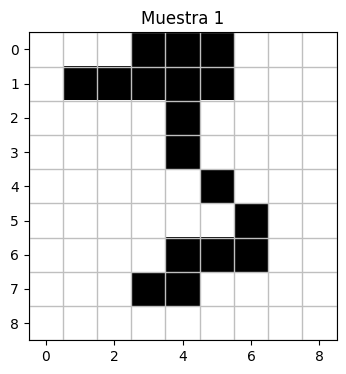

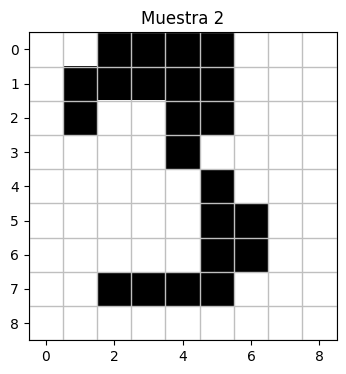

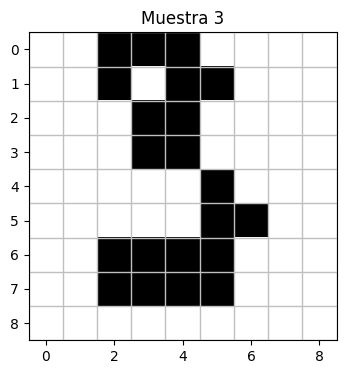

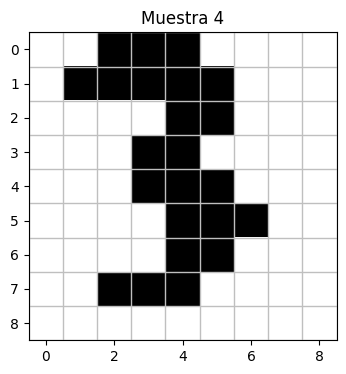

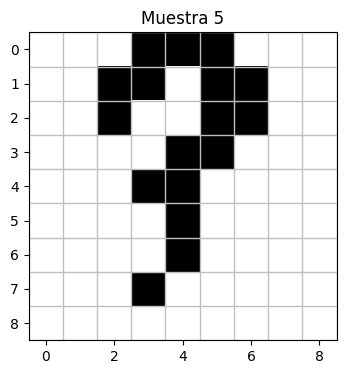

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt

digits = load_digits()

# Elegimos, por ejemplo, solamente el número 3
X_all = digits.images[digits.target == 3]

# Seleccionamos un subconjunto aleatorio de 30 muestras
Nsample = 30
indices = np.random.choice(len(X_all), size=Nsample, replace=False)
X = X_all[indices]

# Binarizamos
Xbin = (X > 8).astype(int)

for k in range(5):
  fig, ax = plt.subplots(figsize=(4,4))
  ax.set_title(f"Muestra {k+1}")
  ax.imshow(Xbin[k], cmap="gray_r", vmin=0, vmax=1)
  ax.set_xticks(np.arange(-0.5, 9, 1), minor=True)
  ax.set_yticks(np.arange(-0.5, 9, 1), minor=True)
  ax.grid(which='minor', color='.75', linestyle='-', linewidth=1)
  ax.tick_params(which='minor', bottom=False, left=False)
  fig.show()

<IPython.core.display.Javascript object>

[[ 0.       0.       0.5      0.96667  1.       0.6      0.       0.     ]
 [ 0.       0.23333  0.96667  0.4      0.7      0.8      0.06667  0.     ]
 [ 0.       0.06667  0.16667  0.13333  0.83333  0.56667  0.03333  0.     ]
 [ 0.       0.       0.       0.6      1.       0.2      0.       0.     ]
 [ 0.       0.       0.       0.2      0.76667  0.76667  0.03333  0.     ]
 [ 0.       0.       0.       0.       0.23333  0.83333  0.4      0.     ]
 [ 0.       0.03333  0.23333  0.26667  0.46667  0.86667  0.33333  0.     ]
 [ 0.       0.       0.63333  1.       0.96667  0.53333  0.03333  0.     ]]


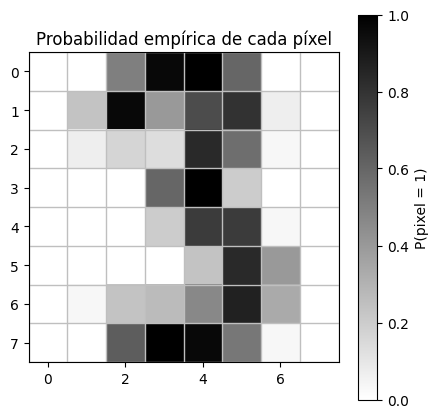

In [19]:
# Probablidad de ocurrenciua de cada unos de los pixeles
np.set_printoptions(precision=5)
p = Xbin.mean(axis=0)
print(p)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(p, cmap="gray_r", vmin=0, vmax=1)
ax.set_xticks(np.arange(-0.5, 8, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
ax.grid(which='minor', color='.75', linestyle='-', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)
fig.colorbar(im, ax=ax, label="P(pixel = 1)")
ax.set_title("Probabilidad empírica de cada píxel")
plt.show()

# ¿Cómo generar nuevos datos?

<IPython.core.display.Javascript object>

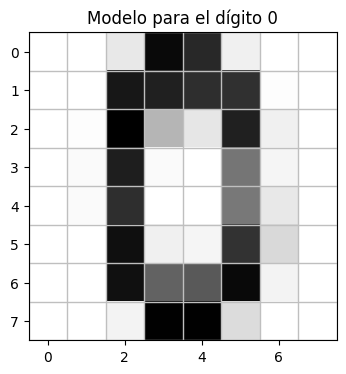

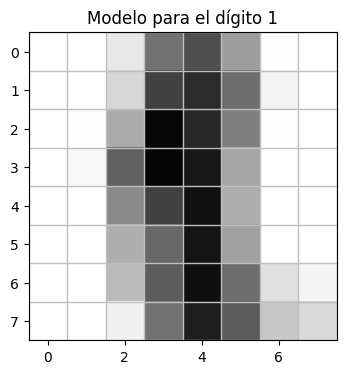

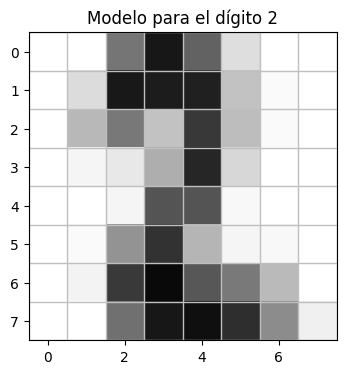

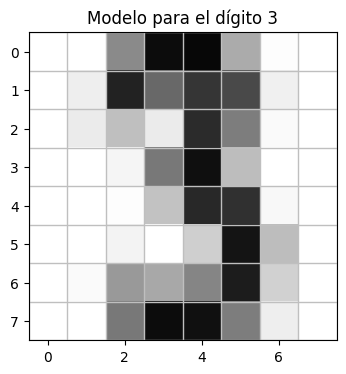

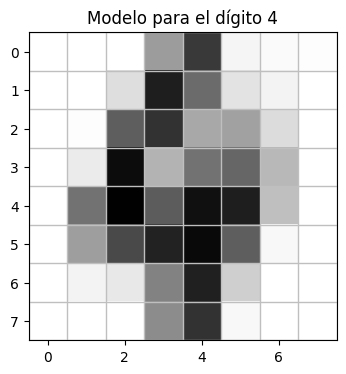

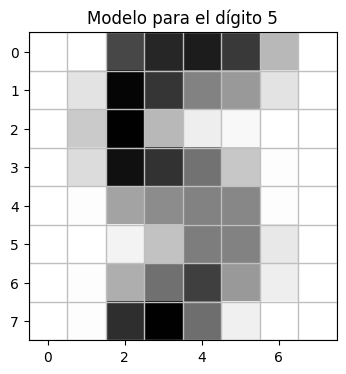

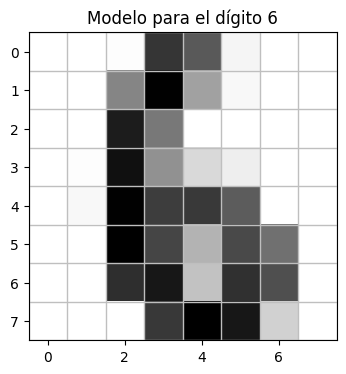

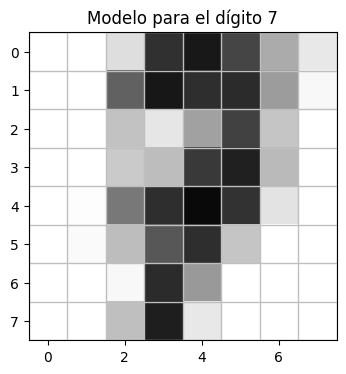

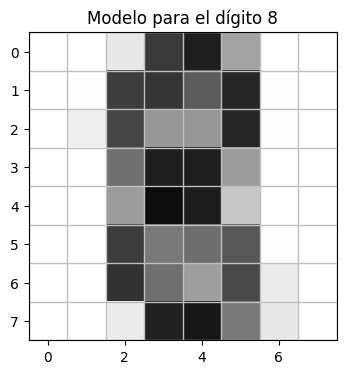

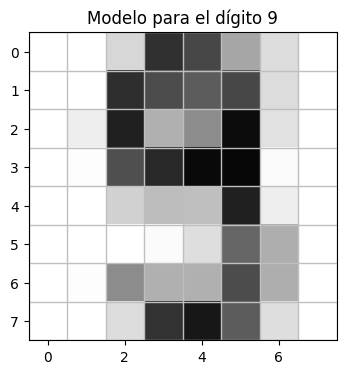

In [20]:
def aprender_modelo(digito, Nsample=100):
    X = digits.images[digits.target == digito]
    X = X[:Nsample]
    # Binarización
    Xbin = (X > 8).astype(int)
    # Probabilidad empírica de pixel = 1
    p = Xbin.mean(axis=0)
    return p

for i in range(10):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_title(f"Modelo para el dígito {i}")
    ax.set_xticks(np.arange(-0.5, 9, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 9, 1), minor=True)
    ax.grid(which='minor', color='.75', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)
    model_p = aprender_modelo(i, Nsample=100)
    ax.imshow(model_p, cmap="gray_r", vmin=0, vmax=1)
    plt.show()

<IPython.core.display.Javascript object>

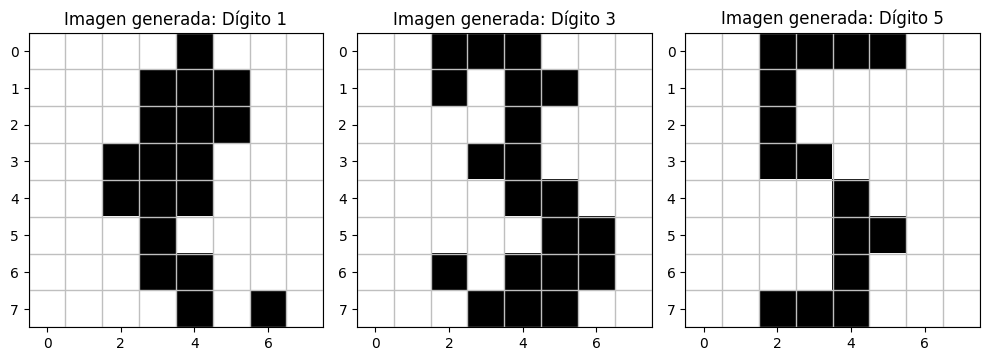

In [21]:
def generar_imagen(p):
    imagen = (np.random.rand(8, 8) < p).astype(int)
    return imagen

digitos_a_generar = {i: aprender_modelo(i, Nsample=100) for i in (1,3,5)}

fig, axes = plt.subplots(1, len(digitos_a_generar), figsize=(10, 4))
for ax, (label, p_val) in zip(axes, digitos_a_generar.items()):
    x_generado = generar_imagen(p_val)
    ax.imshow(x_generado, cmap="gray_r", vmin=0, vmax=1)
    ax.set_xticks(np.arange(-0.5, 8, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
    ax.grid(which='minor', color='.75', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_title(f"Imagen generada: Dígito {label}")
plt.tight_layout()
plt.show()

# Discriminativo

<IPython.core.display.Javascript object>

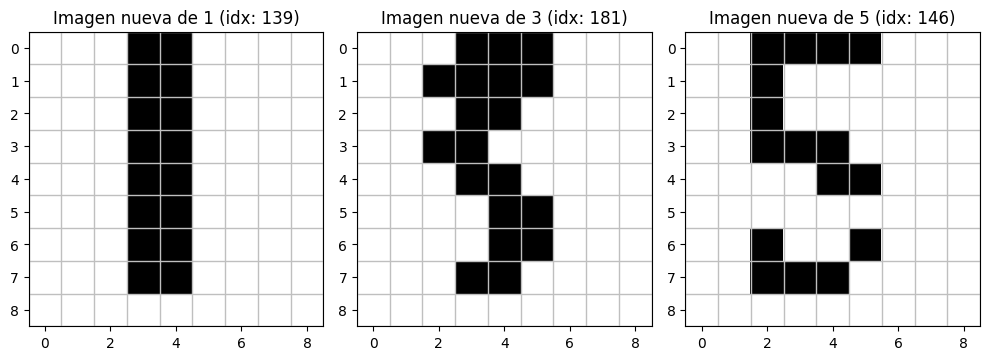

In [22]:
X_dict = {i: digits.images[digits.target == i] for i in (1,3,5)}

# Elegimos una imagen aleatoria posterior a las usadas para entrenar
fig, axes = plt.subplots(1, len(X_dict), figsize=(10, 4))
for ax, (label, X) in zip(axes, X_dict.items()):
  # Seleccionamos un índice aleatorio fuera del set de entrenamiento inicial (Nsample=100)
  idx = np.random.randint(100, len(X))
  x_new = (X[idx] > 8).astype(int)
  ax.imshow(x_new, cmap="gray_r")
  # Set minor ticks between pixels (starting from -0.5 to N-0.5)
  ax.set_xticks(np.arange(-0.5, 9, 1), minor=True)
  ax.set_yticks(np.arange(-0.5, 9, 1), minor=True)
  ax.grid(which='minor', color='.75', linestyle='-', linewidth=1)
  ax.tick_params(which='minor', bottom=False, left=False)
  ax.set_title(f"Imagen nueva de {label} (idx: {idx})")
plt.tight_layout()
plt.show()

In [23]:
# Función para calcular la log-verosimilitud de una imagen binaria dado un mapa de probabilidades
def log_probabilidad_imagen(x, p):
    # Se usa un épsilon pequeño para evitar errores de log(0)
    eps = sys.float_info.epsilon
    p = np.clip(p, eps, 1-eps)
    # Fórmula de Log-Verosimilitud de Bernoulli: sum(x*log(p) + (1-x)*log(1-p))
    logP = np.sum(
        x*np.log(p)
        +
        (1-x)*np.log(1-p)
    )
    return logP

# Calcular log-verosimilitudes para la nueva imagen frente a los modelos de los dígitos 1 y 3
logP_1 = log_probabilidad_imagen(x_new, p1)
logP_3 = log_probabilidad_imagen(x_new, p3)

# Mostrar los resultados usando Markdown
dMarkdown(f"**Log-verosimilitudes:**")
dMarkdown(f"* $\\log P(x \\mid 1) = {logP_1:.4f}$")
dMarkdown(f"* $\\log P(x \\mid 3) = {logP_3:.4f}$")

# Calcular puntajes log-posteriores asumiendo priors iguales (P(1) = P(3) = 0.5)
log_score_1 = logP_1 + np.log(0.5)
log_score_3 = logP_3 + np.log(0.5)

# Realizar la clasificación basada en qué puntaje logarítmico es mayor
prediccion = 1 if log_score_1 > log_score_3 else 3
dMarkdown(f"**Predicción Final:** El modelo clasifica la imagen como un **{prediccion}**")

<IPython.core.display.Javascript object>

**Log-verosimilitudes:**

* $\log P(x \mid 1) = -45.6933$

* $\log P(x \mid 3) = -39.1803$

**Predicción Final:** El modelo clasifica la imagen como un **3**

In [24]:
# Funcion clasificadora con dMarkdown
def clasificar(x, p1, p3):
    logP1 = log_probabilidad_imagen(x, p1) + np.log(0.5)
    logP3 = log_probabilidad_imagen(x, p3) + np.log(0.5)
    pred = 1 if logP1 > logP3 else 3
    dMarkdown(f"""### Resultado de Clasificación
* **Score Log-Posterior (1):** {logP1:.4f}
* **Score Log-Posterior (3):** {logP3:.4f}
* **Predicción:** El dídgito es un **{pred}**
    """)
    return pred

pred = clasificar(X_dict[1][50], p1, p3)

<IPython.core.display.Javascript object>

### Resultado de Clasificación
* **Score Log-Posterior (1):** -18.3715
* **Score Log-Posterior (3):** -181.7862
* **Predicción:** El dídgito es un **1**
    